# Image Latents

Pick a random-walk sequence, encode its images with the autoencoder, and plot the selected latent values.

In [1]:
import importlib.util, sys
from pathlib import Path
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve()
if (ROOT / "gnn_spatial_reasoning_nips").is_dir():
    ROOT = ROOT / "gnn_spatial_reasoning_nips"
sys.path.append(str(ROOT.parent))

spec = importlib.util.spec_from_file_location("base", ROOT / "training_scripts/2_translation_transformer.py")
base = importlib.util.module_from_spec(spec)
sys.modules["base"] = base
spec.loader.exec_module(base)

device = base.device
weights = Path("/cluster/scratch/btuncay/cog/gnn_spatial_reasoning/1_model/0420_nips/model_weights_7800.pt")
roots = [Path(r.replace("../../../scratch", "/cluster/scratch")) for r in base.rw_list]
roots = [r for r in roots if r.is_dir()]
for i, r in enumerate(roots):
    print(i, base.scene_name_from_root(r), r)
print("device:", device)

0 rw_translation /cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_translation
1 anlieferung /cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/random_walks
2 break_room /cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/break_room/random_walks
3 relief /cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/relief/random_walks
4 terrains /cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/terrains/random_walks
5 rw_translation /cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/office/rw_translation
6 office /cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/office/random_walks
device: cpu


In [2]:
ROOT_INDEX = 0
WALK_ID = 10    # None = first walk in root
FRAME = 0          # chosen image from the sequence
LATENT_DIM = 0     # dimension to plot over time
TOP_K = 16

root = roots[ROOT_INDEX]
walks = sorted({base.parse_random_walk_name(p)[0] for p in root.glob("rw_*_*.pt")})
walk = walks[0] if WALK_ID is None else WALK_ID
print("walks:", walks[:20], "..." if len(walks) > 20 else "")
print("selected:", base.scene_name_from_root(root), "walk", walk)

walks: [6, 7, 10, 11, 12, 13, 14, 16, 18, 19, 21, 22, 23, 24] 
selected: rw_translation walk 10


In [3]:
model = base.load_encoder(weights, base.LATENT_DIM).eval()
loader = base.make_loader(root, batch_size=1, shuffle=False, num_workers=0, pattern=f"rw_{walk}_*.pt")

items = []
with torch.inference_mode():
    for batch in loader:
        paths, imgs_cpu = list(batch.path), batch.img.cpu()
        imgs = batch.to(device).img.permute(0, 3, 1, 2).float().contiguous()
        _, z, s = model.img_enc(imgs)
        for path, img, latent, var in zip(paths, imgs_cpu, z.cpu(), s.cpu()):
            items.append((*base.parse_random_walk_name(path), path, img, latent, var))

items.sort(key=lambda x: x[1])
steps = torch.tensor([x[1] for x in items])
paths = [x[2] for x in items]
images = torch.stack([x[3] for x in items])
latents = torch.stack([x[4] for x in items])
logvar = torch.stack([x[5] for x in items])

i = max(0, min(FRAME, len(items) - 1))
d = max(0, min(LATENT_DIM, latents.shape[1] - 1))


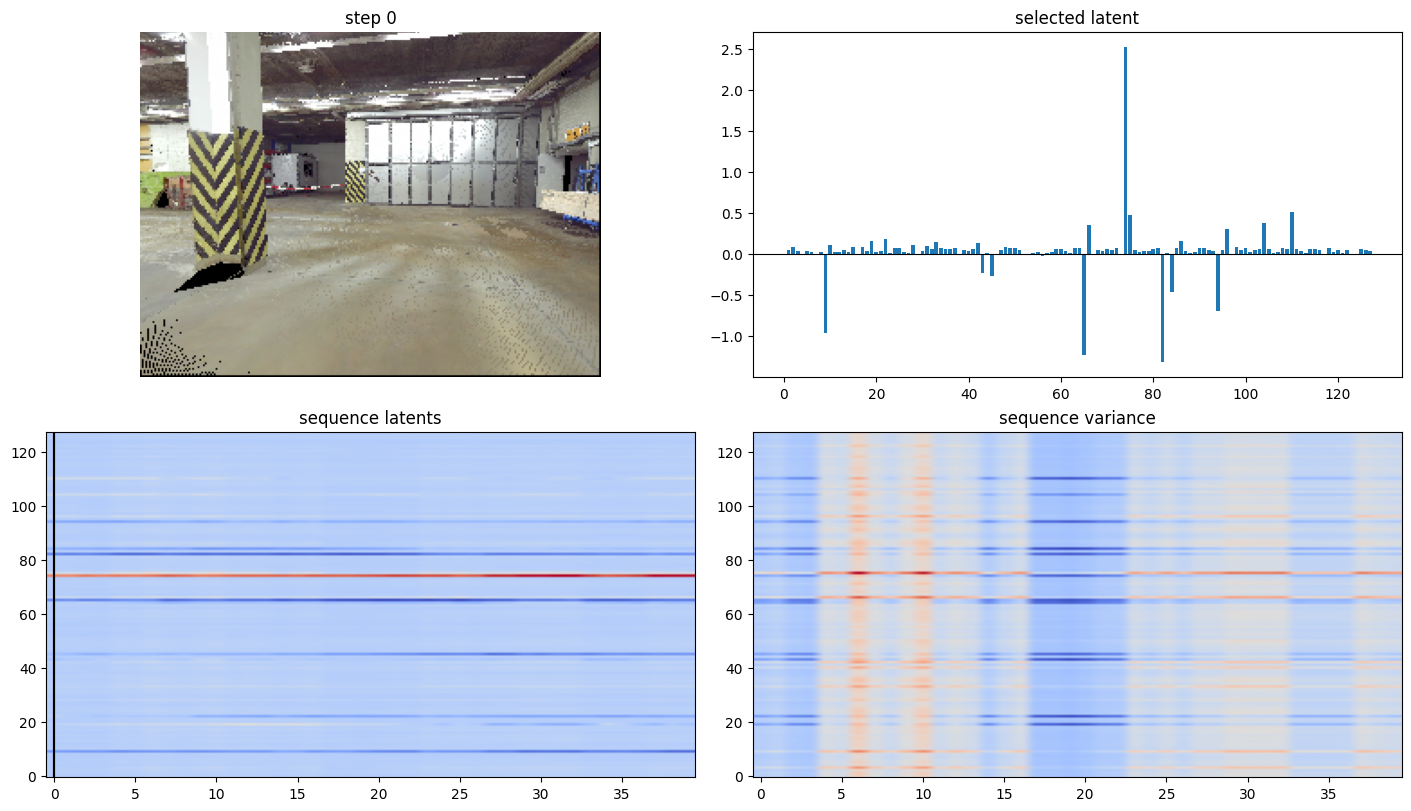

/cluster/scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_translation/rw_10_0.pt
top dims: [(74, 2.520265817642212), (82, -1.3078258037567139), (65, -1.2242732048034668), (9, -0.9562687873840332), (94, -0.6959044933319092), (110, 0.5178353786468506), (75, 0.48384562134742737), (84, -0.46115559339523315), (104, 0.37800902128219604), (66, 0.3551787734031677), (96, 0.3115491271018982), (45, -0.26360341906547546), (43, -0.22407731413841248), (22, 0.1908310204744339), (19, 0.15857483446598053), (86, 0.15818887948989868)]


In [8]:
img, z = images[i].float(), latents[i]
if img.max() > 2:
    img = img / 255
top = torch.argsort(z.abs(), descending=True)[:TOP_K]

fig, ax = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
ax[0, 0].imshow(img.clamp(0, 1)); ax[0, 0].set_title(f"step {steps[i].item()}"); ax[0, 0].axis("off")
ax[0, 1].bar(torch.arange(len(z)), z); ax[0, 1].axhline(0, color="black", lw=.8); ax[0, 1].set_title("selected latent")
ax[1, 0].imshow(latents.T, aspect="auto", origin="lower", cmap="coolwarm"); ax[1, 0].axvline(i, color="black"); ax[1, 0].set_title("sequence latents")
ax[1, 1].imshow(logvar.T, aspect="auto", origin="lower", cmap="coolwarm"); ax[1, 0].axvline(i, color="black"); ax[1, 1].set_title("sequence variance")
#ax[1, 1].plot(steps, latents[:, d], marker="o"); ax[1, 1].scatter([steps[i]], [latents[i, d]], c="red"); ax[1, 1].set_title(f"dim {d} over sequence")
#ax[1, 1].plot(steps, logvar[:, d], marker="o"); ax[1, 1].scatter([steps[i]], [logvar[i, d]], c="red"); ax[1, 1].set_title(f"dim {d} over sequence")
plt.show()

print(paths[i])
print("top dims:", [(int(j), float(z[j])) for j in top])

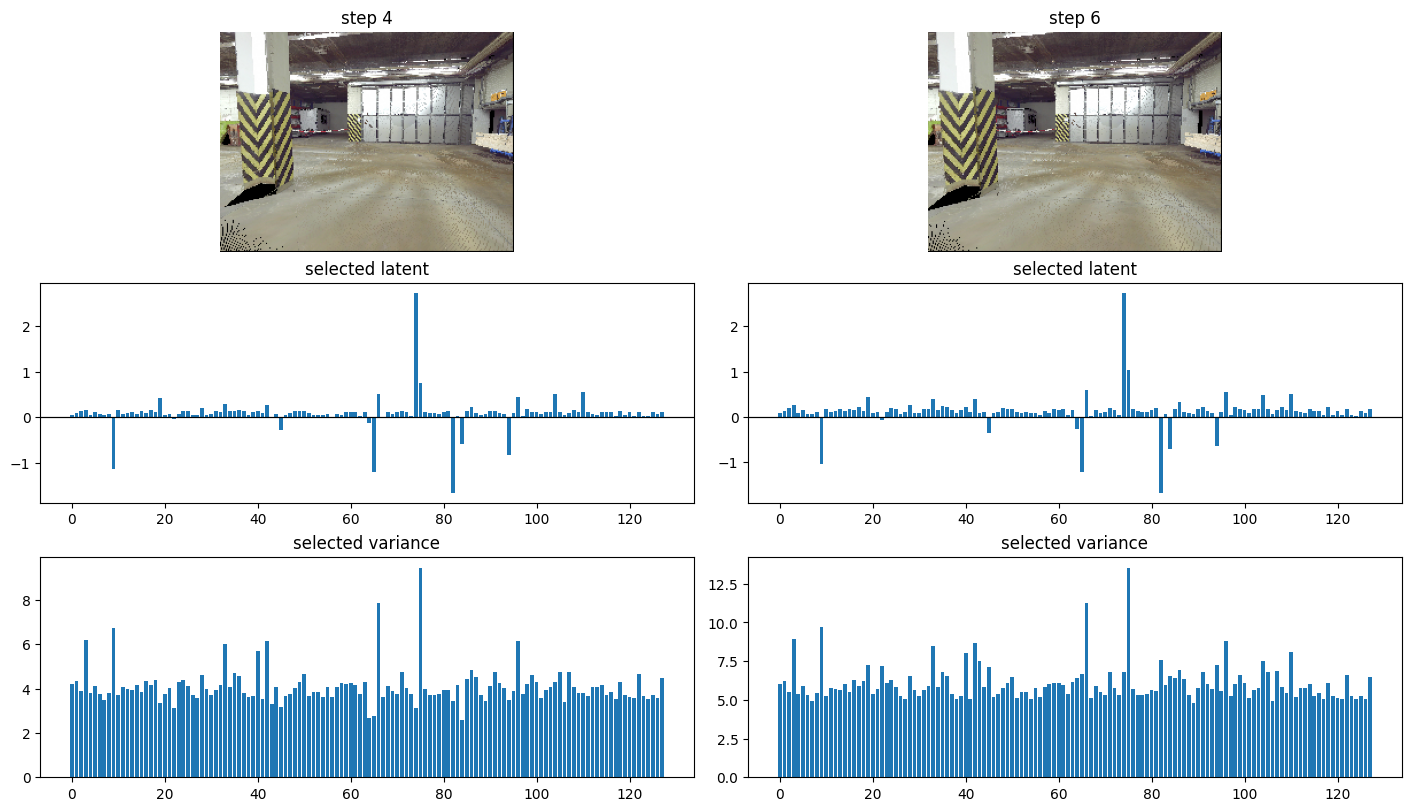

In [16]:
step = 4
diff = 2
fig, ax = plt.subplots(3, 2, figsize=(14, 8), constrained_layout=True)
ax[0, 0].imshow(images[step].clamp(0, 1)); ax[0, 0].set_title(f"step {steps[step].item()}"); ax[0, 0].axis("off")
ax[0, 1].imshow(images[step+diff].clamp(0, 1)); ax[0, 1].set_title(f"step {steps[step+diff].item()}"); ax[0, 1].axis("off")
ax[1, 0].bar(torch.arange(len(latents[step])), latents[step]); ax[1, 0].axhline(0, color="black", lw=.8); ax[1, 0].set_title("selected latent")
ax[1, 1].bar(torch.arange(len(latents[step+diff])), latents[step+diff]); ax[1, 1].axhline(0, color="black", lw=.8); ax[1, 1].set_title("selected latent")
ax[2, 0].bar(torch.arange(len(logvar[step])), logvar[step]); ax[1, 0].axhline(0, color="black", lw=.8); ax[2, 0].set_title("selected variance")
ax[2, 1].bar(torch.arange(len(logvar[step+diff])), logvar[step+diff]); ax[1, 1].axhline(0, color="black", lw=.8); ax[2, 1].set_title("selected variance")
#ax[1, 0].imshow(latents.T, aspect="auto", origin="lower", cmap="coolwarm"); ax[1, 0].axvline(i, color="black"); ax[1, 0].set_title("sequence latents")
#ax[1, 1].plot(steps, latents[:, d], marker="o"); ax[1, 1].scatter([steps[i]], [latents[i, d]], c="red"); ax[1, 1].set_title(f"dim {d} over sequence")
plt.show()

### View $\leftrightarrow$ View Transforms

In [31]:
import torch
from typing import Tuple

def normalize(v: torch.Tensor, eps: float = 1e-9) -> torch.Tensor:
    return v / v.norm(dim=-1, keepdim=True).clamp_min(eps)

def camera_frame_axes(
    view_dir: torch.Tensor,
    eps: float = 1e-9,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    forward = normalize(view_dir.float(), eps=eps)
    world_up = forward.new_tensor([0.0, 0.0, 1.0]).expand_as(forward)

    right = torch.cross(world_up, forward, dim=-1)
    right_norm = right.norm(dim=-1, keepdim=True)
    bad_right = right_norm.squeeze(-1) < eps
    if bool(bad_right.any()):
        candidates = torch.eye(3, device=forward.device, dtype=forward.dtype)
        fallback_up = candidates[torch.argmin(torch.abs(forward @ candidates.T), dim=-1)]
        fallback_right = torch.cross(fallback_up, forward, dim=-1)
        right = torch.where(bad_right.unsqueeze(-1), fallback_right, right)

    right = normalize(right, eps=eps)
    local_up = normalize(torch.cross(forward, right, dim=-1), eps=eps)
    return forward, right, local_up

def camera_transform(
    dir1: torch.Tensor,
    loc1: torch.Tensor,
    dir2: torch.Tensor,
    loc2: torch.Tensor,
    eps: float = 1e-9,
) -> torch.Tensor:
    squeeze = dir1.dim() == 1
    if squeeze:
        dir1 = dir1.unsqueeze(0)
        loc1 = loc1.unsqueeze(0)
        dir2 = dir2.unsqueeze(0)
        loc2 = loc2.unsqueeze(0)

    forward, right, local_up = camera_frame_axes(dir1, eps=eps)
    target_forward = normalize(dir2.float(), eps=eps)
    world_to_local = torch.stack([forward, right, local_up], dim=-2)

    delta = torch.bmm(world_to_local, (loc2.float() - loc1.float()).unsqueeze(-1)).squeeze(-1)
    target_dir = torch.bmm(world_to_local, target_forward.unsqueeze(-1)).squeeze(-1)
    d1_xy = normalize(dir1[:,:2]) # project on xy plane
    d2_xy = normalize(dir2[:,:2])
    d1 = torch.atan2(d1_xy[:,0],d1_xy[:,1])
    d2 = torch.atan2(d2_xy[:,0],d2_xy[:,1])
    out = torch.stack(
        [
            delta[:, 0],
            delta[:, 1],
            delta[:, 2],
            #torch.atan2(delta[:, 1], delta[:, 0]),
            #torch.atan2(target_dir[:, 1], target_dir[:, 0]),
            d2-d1,

        ],
        dim=-1,
    )
    return out.squeeze(0) if squeeze else out

def pairwise_camera_transforms(
    view_dirs: torch.Tensor,
    locs: torch.Tensor,
    ) -> torch.Tensor:
    return [camera_transform(view_dirs[0], locs[0], view_dirs[1], locs[1]).float(),
            camera_transform(view_dirs[1], locs[1], view_dirs[0], locs[0]).float()]

loader = base.make_loader(root, batch_size=1, shuffle=False, num_workers=0, pattern=f"rw_{walk}_*.pt")

items = []
with torch.inference_mode():
    for batch in loader:
        paths, viewdirs, locs = list(batch.path), batch.view_dir.cpu(), batch.loc.cpu()
        for path, viewdir, loc in zip(paths, viewdirs, locs):
            items.append((*base.parse_random_walk_name(path), path, viewdir, loc))

tensor([ 0.9771,  0.1879, -0.0998])
tensor([ 0.9723,  0.2112, -0.0998])
tensor([-0.0048,  0.0233,  0.0000])
tensor([ 0.0048, -0.0233,  0.0000])
tensor([-6.1696,  0.8753, -3.5000])
tensor([-6.0832,  0.8818, -3.5000])
tensor([0.0864, 0.0066, 0.0000])
view 4 -> 5 tensor([ 0.0857, -0.0099,  0.0086, -0.0239])
view 5 -> 4 tensor([-0.0854,  0.0119, -0.0086,  0.0239])


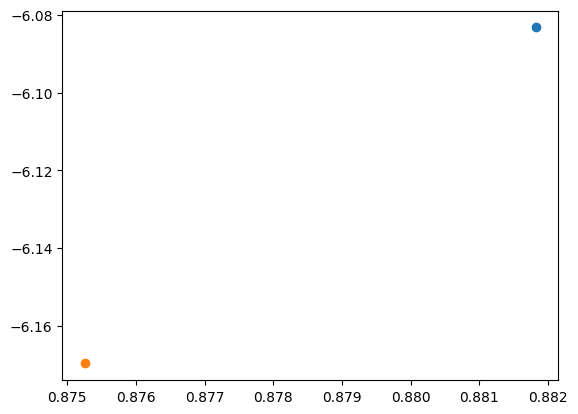

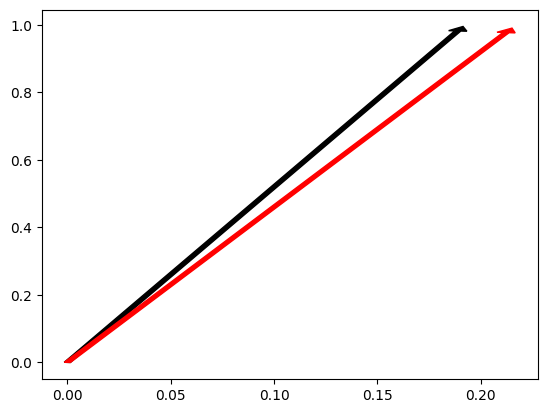

In [32]:
import matplotlib.pyplot as plt

step = 4
diff = 1

view1 = items[step]
view2 = items[step+diff]

print(view1[3])
print(view2[3])
print(view2[3]-view1[3])
print(view1[3]-view2[3])
print(view1[4])
print(view2[4])
print(view2[4]-view1[4])
tr1,tr2 = pairwise_camera_transforms([view1[3],view2[3]],[view1[4],view2[4]])
print('view', step, '->', step+diff, tr1)
print('view', step+diff, '->', step, tr2)
plt.scatter(view2[4][1],view2[4][0])
plt.scatter(view1[4][1],view1[4][0])

plt.figure()
k = 10
plt.arrow(0,0,view1[3][1]/torch.norm(view1[3][:2]),view1[3][0]/torch.norm(view1[3][:2]),width=0.003,color='k')
plt.arrow(0,0,view2[3][1]/torch.norm(view2[3][:2]),view2[3][0]/torch.norm(view2[3][:2]),width=0.003,color='r')